## IMPORTS

In [1]:
from pathlib import Path

TEMPLATES_PATH = Path("./templates/")
DATA_PATH = Path("./data/")
REPORTS_PATH = Path("./out/reports/")

In [5]:
# imports
import io
import json
import yaml
from base64 import b64encode
import numpy as np
import pandas as pd
import networkx as nx
import networkx.algorithms.connectivity as nxcon
from networkx.readwrite import json_graph
import matplotlib
import matplotlib.pyplot as plt
import jinja2 as jn
from weasyprint import HTML

# customize matplotlib
font = {'size' : 8}
matplotlib.rc('font', **font)

# init jinja environment
e = jn.Environment(loader=jn.FileSystemLoader(TEMPLATES_PATH))

## DATA

In [6]:
# read yaml data
with open(DATA_PATH / 'group8.yaml', 'r') as file:
    yaml_data = yaml.safe_load(file)

## REPORT

In [7]:
# init report data
report_data = dict()

# update report data
report_data["assessment_info"] = yaml_data["titolo"]
report_data["group_id"] = yaml_data["gruppo"]
report_data["ga_question"] = yaml_data["domandaA"]
report_data["gb_question"] = yaml_data["domandaB"]
report_data["edges_a"] = [(s,t) for e in yaml_data["scelteA"] for s,t in e.items() ]
report_data["edges_b"] = [(s,t) for e in yaml_data["scelteB"] for s,t in e.items() ]

In [8]:
def get_graph_data_uri(buffer):
    # encode svg
    svg = b64encode(buffer.getvalue()).decode()
    # return svg data uri
    return f"data:image/svg+xml;base64,{svg}"    

In [57]:
def get_network_graph(G, graphType = "A"):
    # set conversion inch -> cm
    cm = 1/2.54
    # define type of graph color
    color = "#0000ff" if graphType == "A" else "#FF0000"
    # init buffer
    buffer = io.BytesIO()
    # init figure
    fig, ax = plt.subplots(constrained_layout=True, figsize=(9*cm,9*cm))
    # hide axis
    ax.axis('off')
    
    #-------------------------------------------------------------------------------------------
    # draw network
    # ------------------------------------------------------------------------------------------
    # compute locations
    loc = nx.spring_layout(G, k=0.3, seed=42)
    # draw nodes
    nx.draw_networkx_nodes(G.nodes(), loc, node_color=color, edgecolors=color, ax=ax)
    # mutual preferences
    mutual_prefs = [ e for e in G.edges() if (e[1],e[0]) in G.edges ]
    # non mutual preferences
    non_mutual_prefs = [ e for e in G.edges if e not in mutual_prefs ]
    # draw mutual preferences edges
    nx.draw_networkx_edges(G, loc, edgelist=mutual_prefs, edge_color=color, 
                           arrowstyle='-|>', width=3, arrowsize=17, ax=ax)
    # draw non mutual preferences edges
    nx.draw_networkx_edges(G, loc, edgelist=non_mutual_prefs, edge_color=color, style="--", 
                           arrowstyle='-|>', arrowsize=10, ax=ax)
     # draw labels
    nx.draw_networkx_labels(G, loc, font_color="#FFF", font_weight=True, font_size=14, ax=ax)
    # ------------------------------------------------------------------------------------------
    
    # save figure to buffer
    fig.savefig(buffer, format="svg", bbox_inches='tight', transparent=True, pad_inches=0.05)
    # return svg data uri (from buffer)
    return get_graph_data_uri(buffer)

def get_network_diameter(G):
    # convert network to undirected
    Gu = G.to_undirected()
    # if network is connected
    if nx.is_connected(Gu):
        # return network diameter
        return nx.diameter(Gu)
    # otherwise
    else:
        # get largest connected component
        Gcc_max = sorted(nx.connected_components(Gu), key=len, reverse=True)[0]
        # get largest connected component subgraph
        Gcc_max_graph = Gu.subgraph(Gcc_max)
        # return diameter of largest connected component
        return nx.diamter(Gcc_max_graph)

def get_degree_centralization(Gu):
    # determine n
    n = Gu.order()
    # store centrality values
    centrality_values = dict(Gu.degree()).values()
    # determine max degree
    c_max = max(centrality_values)
    # return network centrality
    return sum([ c_max - value for value in centrality_values ]) / ((n-1)*(n-2))
    
def get_network_stats(G):
    # convert network to undirected
    Gu = G.to_undirected()
    # init links dict
    links = dict()
    # init no indegree dict
    no_indegree = dict()
    # get nodes' neighbors
    for node in G.nodes():
        no_indegree[node]="x" if G.in_degree(node) == 0 else ""
        links[node]=(", ".join(G.neighbors(node)))
    # build stats dataframe
    df = pd.concat([
        pd.Series(links, name="ln"),
        pd.Series(no_indegree, name="ni"),
        pd.Series(nx.degree_centrality(Gu), name="dc").rank(method="dense", ascending=False),
        pd.Series(nx.eigenvector_centrality(Gu), name="ec").rank(method="dense", ascending=False),
        pd.Series(nx.betweenness_centrality(Gu), name="bc").rank(method="dense", ascending=False),
        pd.Series(nx.closeness_centrality(Gu), name="cc").rank(method="dense", ascending=False)
    ], axis=1)
    # add name to tats dataframe index
    df.index.name = "letter"
    # sort index
    df = df.sort_index()
    # return stats tuple
    return (
        dict(
            nodes=G.number_of_nodes(), 
            edges=G.number_of_edges(),
            degree_centralization=get_degree_centralization(Gu),
            clustering_coefficient=nx.average_clustering(Gu)
        ),
        df
    )

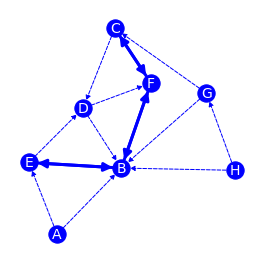

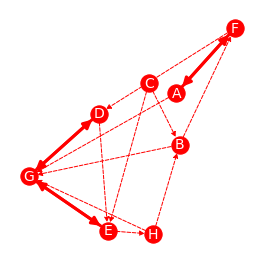

In [58]:
# create DiGraph A
Ga = nx.DiGraph()
Ga.add_edges_from(report_data["edges_a"])
Ga_info, Ga_data = get_network_stats(Ga)
report_data["ga_info"] = Ga_info
report_data["ga_data"] = Ga_data.to_dict("index")
report_data["ga_graph"] = get_network_graph(Ga, "A")

# create DiGraph B
Gb = nx.DiGraph()
Gb.add_edges_from(report_data["edges_b"])
Gb_info, Gb_data = get_network_stats(Gb)
report_data["gb_info"] = Gb_info
report_data["gb_data"] = Gb_data.to_dict("index")
report_data["gb_graph"] = get_network_graph(Gb, "B")

# get report template
tpl = e.get_template("ABGrid_report.html")

# render report
rendered_tpl = tpl.render(report_data);

# save report as pdf
HTML(string=rendered_tpl).write_pdf( REPORTS_PATH / f"ABGrid_report_gruppo_{report_data['group_id']}.pdf")